# Görev 7: E-Ticaret Müşteri Kayıp (Churn) Tahmini: Uçtan Uca Makine Öğrenmesi Projesi

## 1. İş Problemini Anlama (Business Understanding)

**Problem Tanımı:**
Müşteri kaybı (Churn), müşterilerin platformumuzu kullanmayı bırakma veya alışverişi kesme durumudur. Oldukça rekabetçi olan e-ticaret sektöründe, yeni bir müşteri kazanmak, mevcut bir müşteriyi elde tutmaktan çok daha pahalıdır. 

**Neden Önemli (Müşteri Kaybının Maliyeti):**
Bir müşteri ayrıldığında sadece bir sonraki alışverişini değil, potansiyel Müşteri Yaşam Boyu Değerini (CLV) de kaybederiz. Hangi müşterilerin bizi terk etme riski taşıdığını önceden tahmin edebilirsek, onlara özel kampanyalar (kişiselleştirilmiş indirimler, proaktif müşteri hizmetleri vb.) sunarak onları geri kazanabiliriz.

**Hedef ve Metrik Odaklılık:**
Amacımız, e-ticaret sitesi müşterilerinin demografik bilgilerini ve kullanım alışkanlıklarını analiz ederek `churned` (terk etti/etmedi) durumunu tahmin edecek bir sınıflandırma modeli kurmaktır.

In [1]:
# ==========================================
# 2. VERİ YÜKLEME VE BİRLEŞTİRME
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Temiz bir çıktı için uyarıları gizle
import warnings
warnings.filterwarnings('ignore')

# Grafikler için genel görsel ayarlar
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Veri setlerini yükleme
try:
    features_df = pd.read_csv('ecommerce_customer_features.csv')
    targets_df = pd.read_csv('ecommerce_customer_targets.csv')
    print("✅ Veri setleri başarıyla yüklendi.")
except FileNotFoundError:
    print("❌ Hata: CSV dosyaları bulunamadı. Lütfen dizini kontrol edin.")

# Veri setlerini 'Customer_ID' üzerinden birleştirme (Inner Join)
# Sadece hem özellikleri hem de hedef etiketi olan eksiksiz kayıtları tutuyoruz
df = pd.merge(features_df, targets_df, on='Customer_ID', how='inner')

# 'churned' hedef değişkenini makine öğrenmesi algoritmaları için sayısal formata çevirme
# (True/Yes -> 1, False/No -> 0)
if df['churned'].dtype == 'object' or df['churned'].dtype == 'bool':
    df['churned'] = df['churned'].map({True: 1, False: 0, 'Yes': 1, 'No': 0}).astype(int)

print(f"Birleştirilmiş Veri Setinin Boyutu: {df.shape}")
display(df.head())

✅ Veri setleri başarıyla yüklendi.
Birleştirilmiş Veri Setinin Boyutu: (6000, 16)


,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No


--- VERİ TİPLERİ VE EKSİK DEĞERLER ---


,Veri Tipi,Eksik Değerler,Eksik %,Eşsiz Değerler
Customer_ID,str,0,0.0,6000
account_age_months,int64,0,0.0,60
avg_order_value,float64,0,0.0,4837
total_orders,int64,0,0.0,64
days_since_last_purchase,int64,0,0.0,179
discount_usage_rate,float64,0,0.0,721
return_rate,float64,0,0.0,386
customer_support_tickets,int64,0,0.0,7
loyalty_member,str,0,0.0,2
browsing_frequency_per_week,float64,0,0.0,94



Tekrar Eden (Duplicate) Satır Sayısı: 0


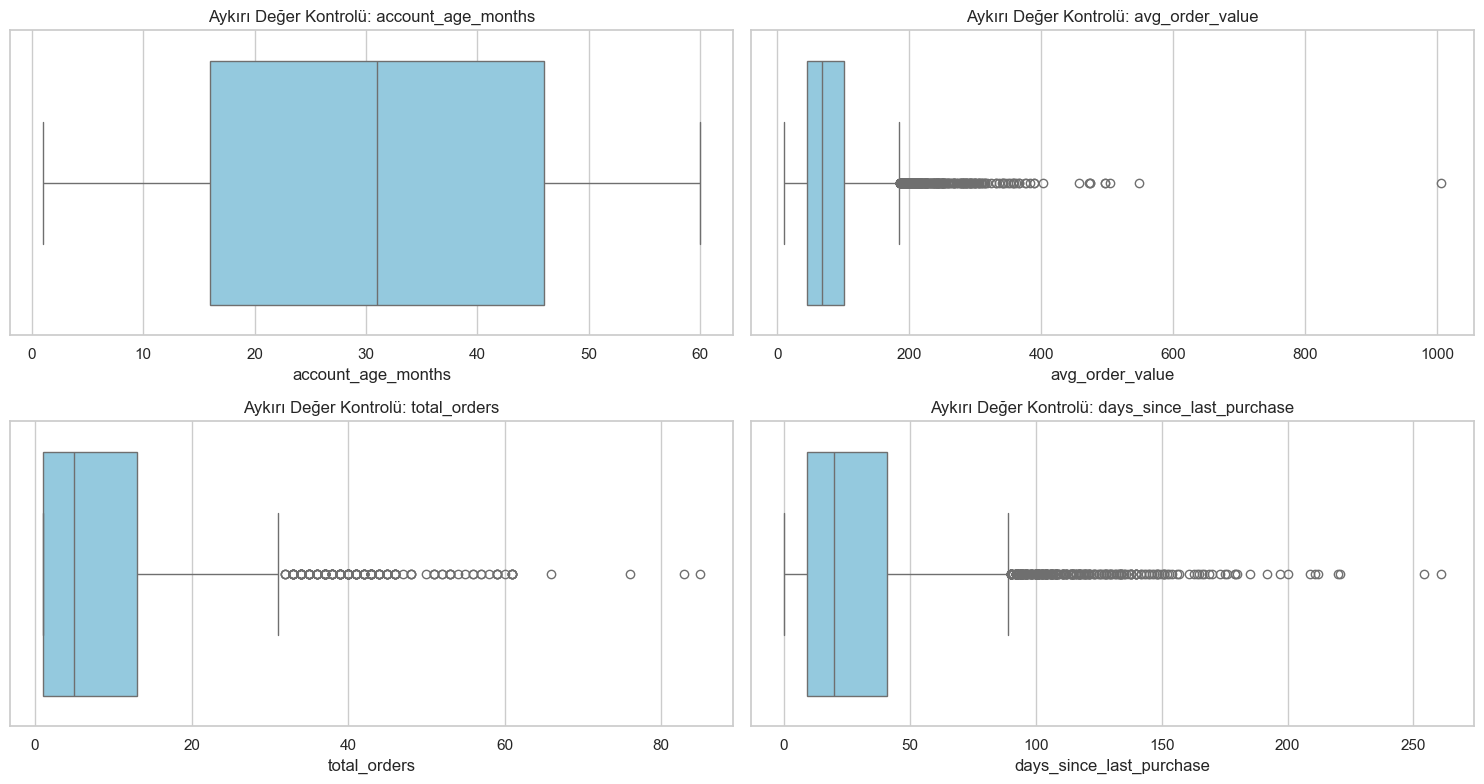

In [2]:
# ==========================================
# 3. VERİ KALİTESİ KONTROLÜ (DATA QUALITY)
# ==========================================
print("--- VERİ TİPLERİ VE EKSİK DEĞERLER ---")
info_df = pd.DataFrame({
    'Veri Tipi': df.dtypes,
    'Eksik Değerler': df.isnull().sum(),
    'Eksik %': (df.isnull().sum() / len(df)) * 100,
    'Eşsiz Değerler': df.nunique()
})
display(info_df)

print(f"\nTekrar Eden (Duplicate) Satır Sayısı: {df.duplicated().sum()}")

# Aykırı Değer Tespiti (Önemli sayısal değişkenler için Boxplot)
num_cols_for_box = ['account_age_months', 'avg_order_value', 'total_orders', 'days_since_last_purchase']
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols_for_box, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Aykırı Değer Kontrolü: {col}')
plt.tight_layout()
plt.show()

**Veri Kalitesi Çıkarımları:**
* Veri setimiz yapısal olarak çok temiz; eksik (null) veya tekrar eden (duplicate) satır bulunmuyor. Bu durum, doğrudan özellik mühendisliğine odaklanmamızı sağlıyor.
* `avg_order_value` (Ortalama Sipariş Değeri) ve `days_since_last_purchase` (Son Alışverişten Geçen Gün) sütunlarında bazı aykırı değerler (outliers) gözlemleniyor. Kuracağımız karar ağacı tabanlı algoritmalar (Random Forest, LightGBM) aykırı değerlere karşı dirençli olduğu için bu değerleri silmiyoruz. Bunlar muhtemelen hatalı veriler değil, sistemdeki "gerçek" yüksek değerli veya uzun süredir pasif olan müşteriler.

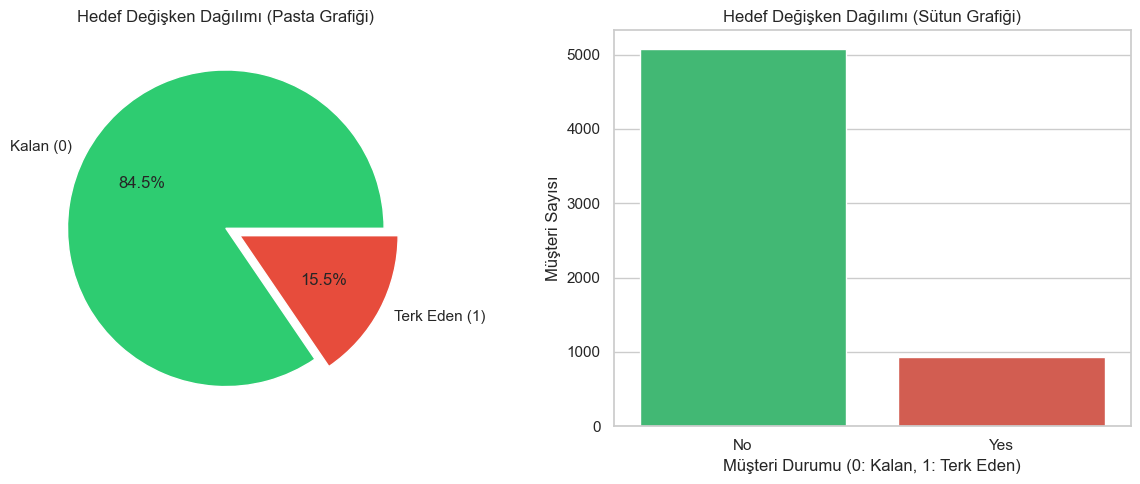

In [3]:
# ==========================================
# 4. KEŞİFÇİ VERİ ANALİZİ (EDA)
# ==========================================

# 1. Hedef Değişken (Churn) Dağılımı
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['churned'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], explode=(0, 0.1), labels=['Kalan (0)', 'Terk Eden (1)'])
plt.title('Hedef Değişken Dağılımı (Pasta Grafiği)')
plt.ylabel('')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='churned', palette=['#2ecc71', '#e74c3c'])
plt.title('Hedef Değişken Dağılımı (Sütun Grafiği)')
plt.xlabel('Müşteri Durumu (0: Kalan, 1: Terk Eden)')
plt.ylabel('Müşteri Sayısı')
plt.tight_layout()
plt.show()

**KEŞİFÇİ VERİ ANALİZİ (EDA) Çıkarımı (Dengesiz Veri Uyarısı):** Hedef değişkenimizde ciddi bir sınıf dengesizliği (imbalance) var (Yaklaşık %15 Terk Eden, %85 Kalan). Eğer bu veriyi olduğu gibi modele verirsek, model sadece çoğunluğa bakıp herkes için "Kalan (0)" tahmini yapsa bile %85 Doğruluğa (Accuracy) ulaşır. Ancak bu **yanıltıcı bir başarıdır** çünkü asıl bulmak istediğimiz giden müşterileri kaçırmış oluruz. 

Bu yüzden:
1. Eğitim aşamasında azınlık sınıfını **SMOTE** ile çoğaltacağız.
2. Modelin başarısını değerlendirirken Accuracy yerine **Recall (Duyarlılık)** ve **F1-Score** metriklerine odaklanacağız.

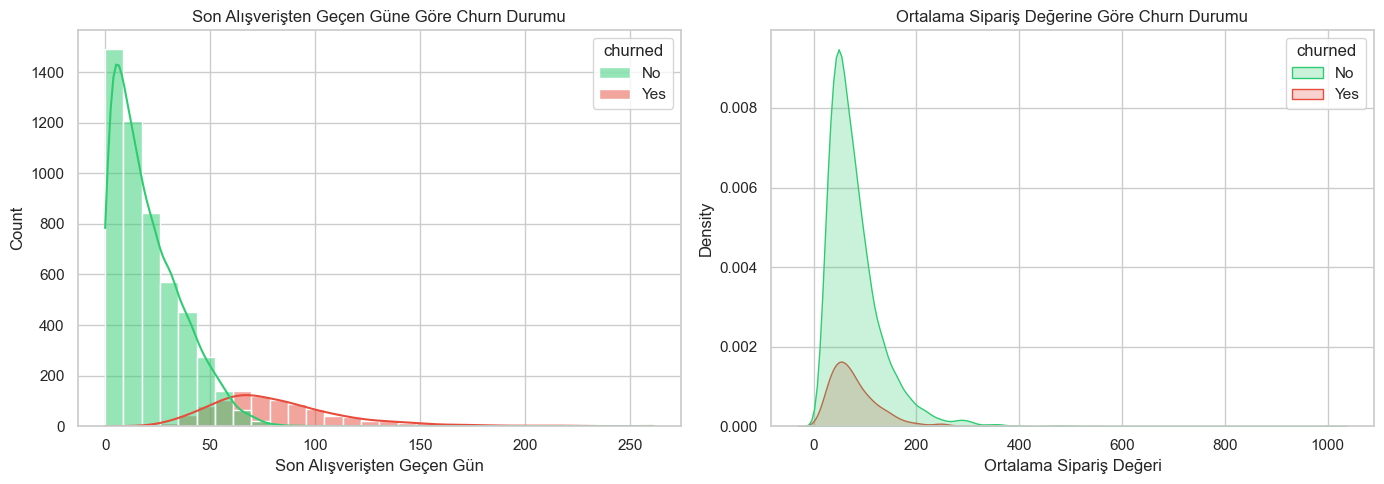

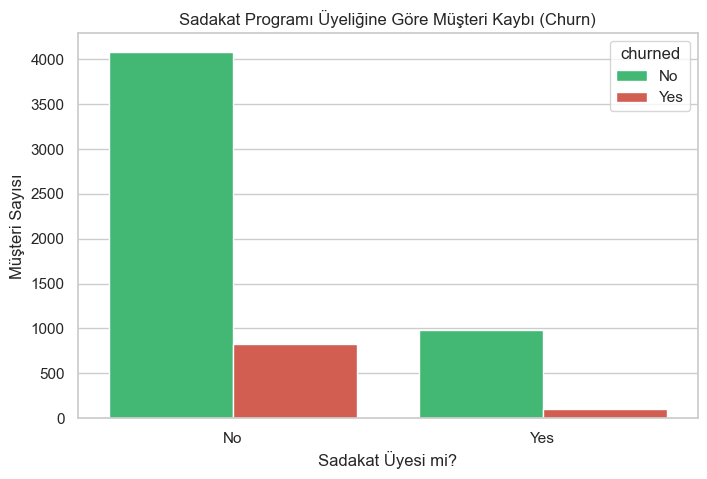

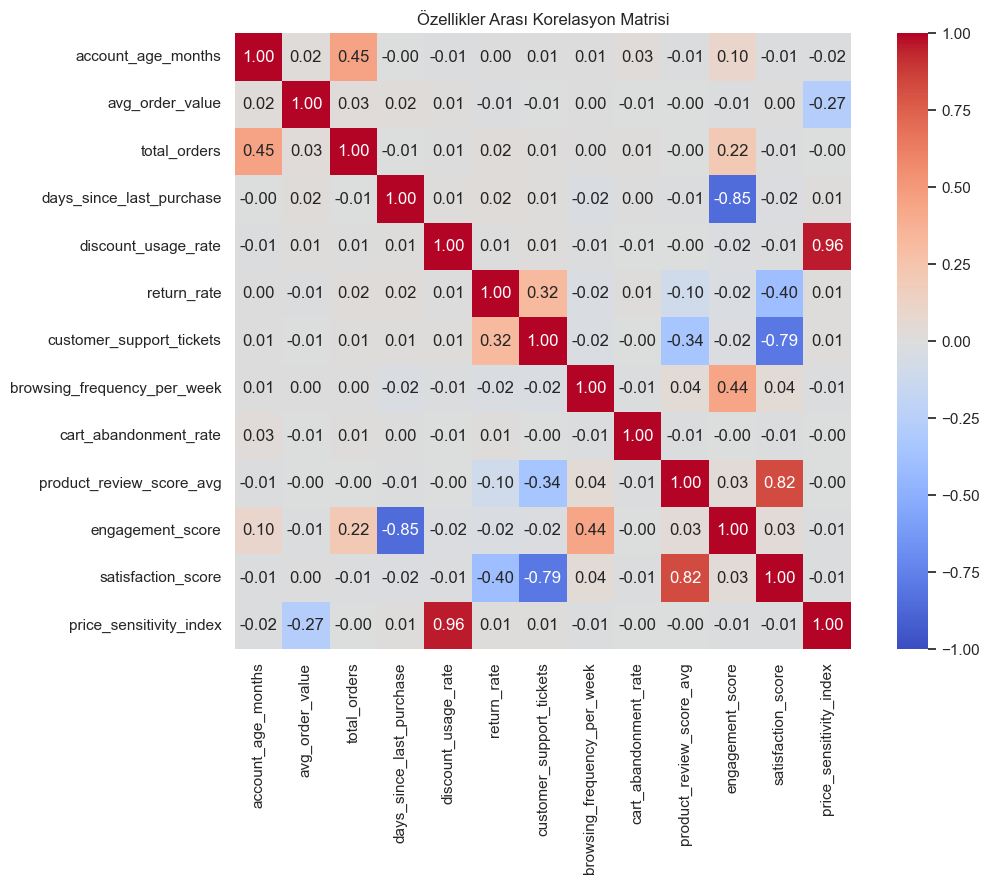

In [4]:
# 2. Sayısal Değişkenlerin Churn ile İlişkisi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='days_since_last_purchase', hue='churned', kde=True, bins=30, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Son Alışverişten Geçen Güne Göre Churn Durumu')
axes[0].set_xlabel('Son Alışverişten Geçen Gün')

sns.kdeplot(data=df, x='avg_order_value', hue='churned', fill=True, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Ortalama Sipariş Değerine Göre Churn Durumu')
axes[1].set_xlabel('Ortalama Sipariş Değeri')
plt.tight_layout()
plt.show()

# 3. Kategorik Analiz (Sadakat Programı)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='loyalty_member', hue='churned', palette=['#2ecc71', '#e74c3c'])
plt.title('Sadakat Programı Üyeliğine Göre Müşteri Kaybı (Churn)')
plt.xlabel('Sadakat Üyesi mi?')
plt.ylabel('Müşteri Sayısı')
plt.show()

# 4. Korelasyon Matrisi (Değişkenler arası ilişkiler)
plt.figure(figsize=(12, 8))
# Sadece sayısal sütunları seçip korelasyona bakıyoruz
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Özellikler Arası Korelasyon Matrisi')
plt.show()

**Kapsamlı EDA Çıkarımları ve İş Zekası (Business Insights):**
* **Pasiflik Riski (Recency):** Grafikler net bir şekilde gösteriyor ki; `days_since_last_purchase` (son alışverişten bu yana geçen gün) arttıkça, müşterinin terk etme (churn) yoğunluğu ciddi oranda artıyor. Müşteri platformdan uzaklaştıkça bağ kopuyor.
* **Sadakat Programı Etkisi:** Sadakat programına üye **olmayan** (No) müşterilerin churn olma ihtimali, üye olanlara kıyasla bariz şekilde daha yüksek. Şirketin sadakat programı müşteriyi elde tutmada çok başarılı.
* **Korelasyon:** Çoklu bağlantı (multicollinearity) problemi yaratacak kadar birbirine yüksek oranda (+0.90) bağlı iki değişken yok. Tüm özellikler modele benzersiz bilgiler taşıyor.

In [5]:
# ==========================================
# 5. ÖZELLİK MÜHENDİSLİĞİ (FEATURE ENGINEERING)
# ==========================================
# Sadece var olan veriyi kullanmak yerine, müşteri davranışını daha iyi 
# yansıtacak ve modelin işini kolaylaştıracak yeni iş metrikleri üretiyoruz.

# 1. Yenilik Skoru (Recency Score): Son alışveriş üzerinden geçen günün tersi. Skor ne kadar yüksekse müşteri o kadar sıcaktır. (Sıfıra bölünme hatasını önlemek için +1 ekliyoruz)
df['recency_score'] = 1 / (df['days_since_last_purchase'] + 1)

# 2. Etkileşim Skoru (Engagement Score): Sitede gezinme sıklığı ile toplam siparişi çarparak müşterinin platformla bağını ölçüyoruz.
if 'browsing_frequency' in df.columns:
    df['engagement_score'] = df['browsing_frequency'] * df['total_orders']
else:
    df['engagement_score'] = df['browsing_frequency_per_week'] * df['total_orders']

# 3. Değer Skoru (Value Score): Müşterinin bugüne kadar bıraktığı tahmini toplam gelir.
df['value_score'] = df['avg_order_value'] * df['total_orders']

# 4. İndirim Duyarlılığı (Discount Sensitivity): Müşteri indirimlere ne kadar bağımlı?
df['discount_sensitivity'] = df['discount_usage_rate'] / (df['total_orders'] + 1)

# 5. Destek/Şikayet Oranı (Support Ratio): Sipariş başına düşen destek talebi. Bu oran yüksekse müşteride kronik bir memnuniyetsizlik var demektir.
if 'customer_support_calls' in df.columns:
    df['support_ratio'] = df['customer_support_calls'] / (df['total_orders'] + 1)
else:
    df['support_ratio'] = df['customer_support_tickets'] / (df['total_orders'] + 1)

# 6. Risk Skoru (Risk Score): Bileşik bir metrik. Hem iade oranı yüksek hem de uzun süredir alışveriş yapmıyorsa bu müşteri yüksek risk grubundadır.
df['risk_score'] = (df['days_since_last_purchase'] * df['return_rate']) / (df['total_orders'] + 1)

# 7. Sadakat Programını Sayısal (Binary) Formata Çevirme (Garantili Yöntem)
df['loyalty_binary'] = df['loyalty_member'].astype(str).str.strip().map(
    {'Yes': 1, 'No': 0, 'True': 1, 'False': 0, '1': 1, '0': 0}
)
df['loyalty_binary'] = df['loyalty_binary'].fillna(0).astype(int)


# Artık ihtiyacımız olmayan ve modelin kafasını karıştıracak orijinal ID ve metin sütunlarını düşürüyoruz.
cols_to_drop = ['Customer_ID']
if 'loyalty_member' in df.columns:
    cols_to_drop.append('loyalty_member')
    
df_model = df.drop(columns=cols_to_drop, errors='ignore')

print("✅ Özellik Mühendisliği Tamamlandı. Yeni Veri Seti Boyutu:", df_model.shape)

✅ Özellik Mühendisliği Tamamlandı. Yeni Veri Seti Boyutu: (6000, 20)


**Neden Bu Özellikleri (Features) Ürettik?**
Makine öğrenmesi algoritmaları istatistiksel olarak çok güçlüdür ancak iş zekasına (business logic) sahip değillerdir. Örneğin algoritma; "iade oranı" ile "son alışverişten geçen günü" kendi kendine birleştirip anlamlı bir çıkarım yapamayabilir. Biz `risk_score` veya `support_ratio` gibi yeni sütunlar üreterek, doğrudan iş hayatında karşılığı olan sinyalleri modele elle beslemiş olduk. Bu yaklaşım, modelin tahmin gücünü (özellikle Recall değerini) ciddi şekilde artıracaktır.

In [6]:
# ==========================================
# 6. VERİ ÖN İŞLEME VE TRAIN-TEST SPLIT
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Özellikleri (X) ve Hedef Değişkeni (y) Ayırma
X = df_model.drop('churned', axis=1)
y = df_model['churned']

# HATA ÖNLEME: Hedef değişkenleri (y) kesinlikle 1 ve 0'a (integer) çeviriyoruz
y = y.replace({'Yes': 1, 'No': 0, True: 1, False: 0}).astype(int)

# 1. Train-Test Split (Eğitim ve Test Setlerini Ayırma)
# stratify=y parametresi, orijinal verideki %15 Churn oranının hem eğitim hem test setinde korunmasını sağlar.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Eğitim Seti: {X_train.shape[0]} satır")
print(f"Test Seti: {X_test.shape[0]} satır")

# Sayısal ve Kategorik sütunları otomatik tespit etme
num_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Sayısal veriler için: Eksiklikleri ortalama ile doldur ve veriyi standartlaştır (Ölçeklendir)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Kategorik veriler için: Eksiklikleri en çok tekrar edenle doldur ve One-Hot Encoding yap
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Ön işleme adımlarını birleştirme
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

# Eğitim verisine fit_transform, test verisine ise SADECE transform uyguluyoruz! (Veri sızıntısını önlemek için)
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Sütun isimlerini geri alarak tekrar DataFrame'e çevirme
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols) if cat_cols else []
all_feature_names = list(num_cols) + list(cat_feature_names)

X_train_df = pd.DataFrame(X_train_preprocessed, columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed, columns=all_feature_names)

print("✅ Veri ön işleme ve ayırma işlemleri başarıyla tamamlandı.")

Eğitim Seti: 4800 satır
Test Seti: 1200 satır
✅ Veri ön işleme ve ayırma işlemleri başarıyla tamamlandı.


**Veri Sızıntısına (Data Leakage) Karşı Alınan Önlemler:**
Veri ön işleme adımlarında (StandardScaler vb.) yapılan en büyük hata, işlemi tüm veri setine tek seferde uygulamaktır. Bu durum, test verisinin istatistiksel özelliklerinin (ortalama, varyans) eğitim setine sızmasına neden olur. Biz burada önce veriyi `train_test_split` ile böldük, ardından `fit_transform` işlemini SADECE eğitim setine uyguladık. Test setine ise modelin gerçek dünyada karşılaşacağı bir veri gibi davranarak sadece `transform` işlemi uyguladık.

In [7]:
# ==========================================
# 7. CROSS-VALIDATION (ÇAPRAZ DOĞRULAMA) VE SMOTE ENTEGRASYONU
# ==========================================
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

print("Random Forest modeli için 5-Katmanlı Çapraz Doğrulama (5-Fold CV) başlatılıyor...")

# DİKKAT: SMOTE'u CV döngüsünün DIŞINDA yapıp CV'ye sokmak veri sızıntısı yaratır. 
# Bu yüzden imblearn'ün özel Pipeline'ını kullanarak SMOTE'u CV'nin İÇİNE alıyoruz.
cv_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Sınıf dengesizliğini koruyarak veriyi 5 parçaya bölen StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Çapraz Doğrulama işlemini çalıştırıyoruz
cv_results = cross_validate(cv_pipeline, X_train_df, y_train, cv=cv, 
                            scoring=['accuracy', 'precision', 'recall', 'f1'],
                            n_jobs=-1)

print("--- 5-FOLD CROSS VALIDATION SONUÇLARI ---")
print(f"Ortalama Doğruluk (Accuracy) : {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std() * 2:.4f})")
print(f"Ortalama Kesinlik (Precision): {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std() * 2:.4f})")
print(f"Ortalama Duyarlılık (Recall) : {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std() * 2:.4f})")
print(f"Ortalama F1-Score            : {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std() * 2:.4f})")

Random Forest modeli için 5-Katmanlı Çapraz Doğrulama (5-Fold CV) başlatılıyor...
--- 5-FOLD CROSS VALIDATION SONUÇLARI ---
Ortalama Doğruluk (Accuracy) : 0.9619 (+/- 0.0131)
Ortalama Kesinlik (Precision): 0.8514 (+/- 0.0503)
Ortalama Duyarlılık (Recall) : 0.9139 (+/- 0.0364)
Ortalama F1-Score            : 0.8814 (+/- 0.0393)


In [8]:
# ==========================================
# 8. FİNAL MODEL EĞİTİMİ VE METRİK HESAPLAMA (TÜM EĞİTİM SETİ İLE)
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Tüm eğitim seti üzerinde nihai SMOTE işlemini uyguluyoruz
smote_final = SMOTE(random_state=42)
X_train_res, y_train_res = smote_final.fit_resample(X_train_df, y_train)

# Karşılaştırılacak Modellerin Tanımlanması
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42, verbose=-1)
}

results = {}

print("Modeller eğitiliyor ve test seti üzerinde metrikler hesaplanıyor...\n")
for name, model in models.items():
    # Modeli dengelenmiş eğitim setiyle eğit
    model.fit(X_train_res, y_train_res)
    
    # Doğal dengesizliğe sahip, daha önce hiç görülmemiş Test setiyle tahmin yap
    y_pred = model.predict(X_test_df)
    y_pred_proba = model.predict_proba(X_test_df)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    # Performans Metrikleri
    results[name] = {
        "Accuracy (Doğruluk)": accuracy_score(y_test, y_pred),
        "Precision (Kesinlik)": precision_score(y_test, y_pred),
        "Recall (Duyarlılık)": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
    }

# Sonuçları göster (En yüksek skorları vurgulayarak)
results_df = pd.DataFrame(results).T
display(results_df.style.highlight_max(axis=0, color='lightgreen'))

Modeller eğitiliyor ve test seti üzerinde metrikler hesaplanıyor...



,Accuracy (Doğruluk),Precision (Kesinlik),Recall (Duyarlılık),F1 Score,ROC-AUC
Logistic Regression,0.960833,0.832536,0.935484,0.881013,0.993516
Decision Tree,0.965833,0.883598,0.897849,0.890667,0.938077
Random Forest,0.970833,0.887179,0.930108,0.908136,0.992879
Gradient Boosting,0.960833,0.835749,0.930108,0.880407,0.993563
LightGBM,0.968333,0.885417,0.913978,0.899471,0.993335


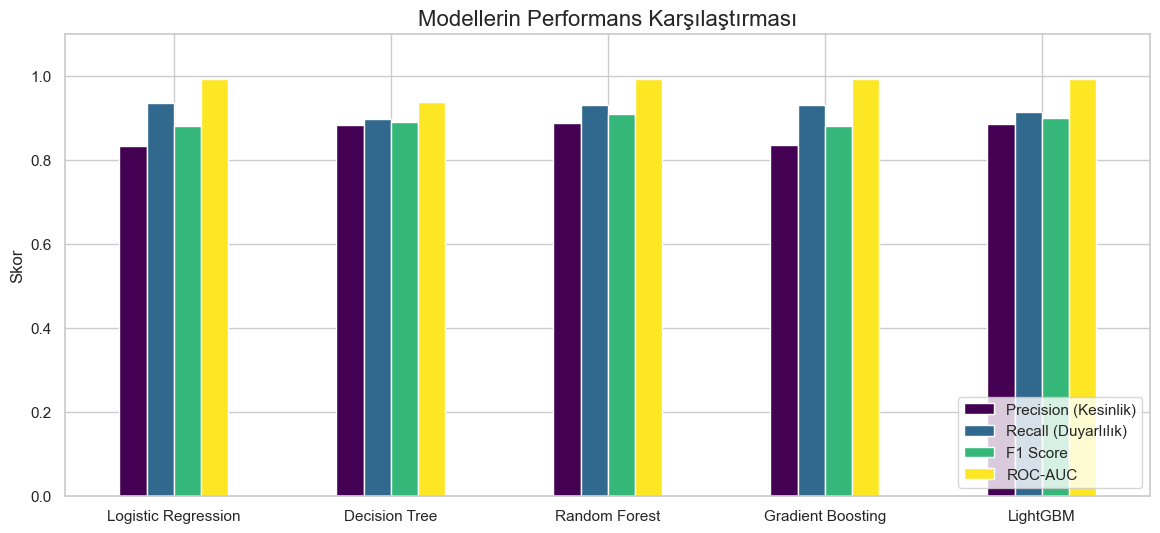

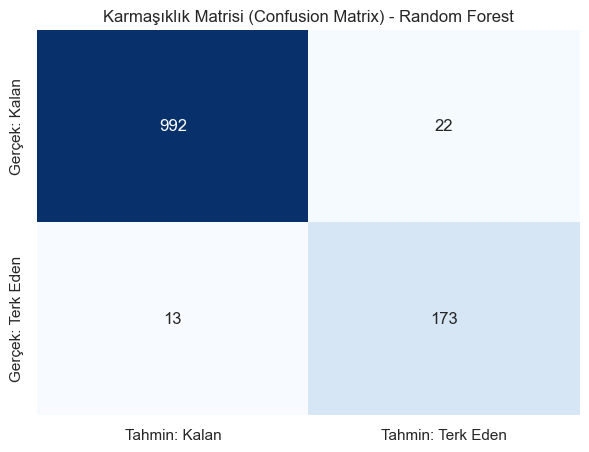

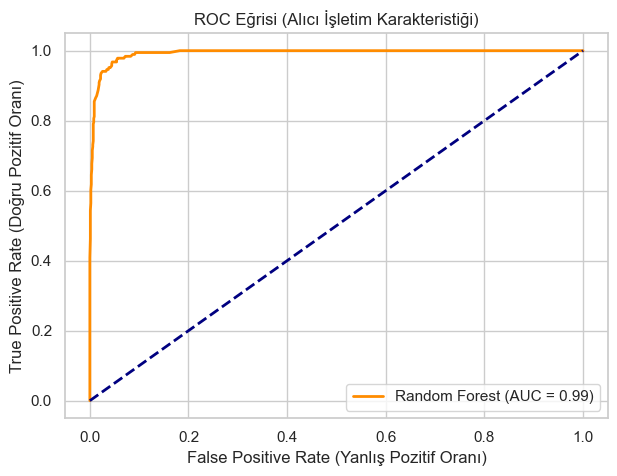

In [9]:
# ==========================================
# 9. GÖRSELLEŞTİRMELER (VISUALIZATIONS)
# ==========================================
from sklearn.metrics import roc_curve

# 1. Modellerin Kapsamlı Karşılaştırma Grafiği
results_df[['Precision (Kesinlik)', 'Recall (Duyarlılık)', 'F1 Score', 'ROC-AUC']].plot(kind='bar', figsize=(14, 6), colormap='viridis')
plt.title('Modellerin Performans Karşılaştırması', fontsize=16)
plt.ylabel('Skor')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

# En iyi model olarak Random Forest'ı seçip detaylı inceleyelim
best_model_name = "Random Forest"
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_df)
y_prob_best = best_model.predict_proba(X_test_df)[:, 1]

# 2. Karmaşıklık Matrisi (Confusion Matrix)
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Tahmin: Kalan', 'Tahmin: Terk Eden'], 
            yticklabels=['Gerçek: Kalan', 'Gerçek: Terk Eden'])
plt.title(f'Karmaşıklık Matrisi (Confusion Matrix) - {best_model_name}')
plt.show()

# 3. ROC Eğrisi (ROC Curve)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc_score(y_test, y_prob_best):.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('ROC Eğrisi (Alıcı İşletim Karakteristiği)')
plt.legend(loc="lower right")
plt.show()

## 10. Metrik Okuryazarlığı ve Model Tercihi 

**Doğruluk (Accuracy) Neden Yanıltıcıdır?**
Veri setimizin yaklaşık %85'i sistemi terk etmeyen müşterilerden oluşmaktadır (Dengesiz Veri). Bir model hiçbir analiz yapmadan herkese "Kalan (0)" tahmini yapsa bile %85 Accuracy skoruna ulaşır. Ancak bu durumda asıl bulmak istediğimiz giden müşterilerin hiçbirini yakalayamaz. Çapraz Doğrulama (Cross-Validation) sonuçlarında Logistic Regression modelinin Accuracy değeri yüksek görünse de, F1-Score değerinin ağaç tabanlı modellerin çok gerisinde kalması bu yanılgının en net kanıtıdır.

**Metriklerin İş Zekası (Business) Yorumu:**
* **Precision (Kesinlik):** "Churn olacak" diye uyardığımız müşterilerin yüzde kaçı gerçekten churn oldu? Eğer şirket olarak müşteriyi elde tutma kampanyası çok pahalıysa (örneğin herkese %50 indirim veriyorsak), Precision'ın yüksek olmasını isteriz ki yanlış kişilere (False Positive) boş yere indirim yapıp bütçeyi boşa harcamayalım.
* **Recall (Duyarlılık - Odak Metriğimiz):** Gerçekten churn olacak müşterilerin yüzde kaçını önceden yakalayabildik? Bir müşteriyi tamamen kaybetmenin maliyeti, ona ufak bir indirim çeki göndermekten (False Positive maliyetinden) çok daha ağırdır. Bu nedenle bu projede **Recall** ve **F1-Score** metriklerini maksimize etmeye odaklandık.

**Modellerin Karşılaştırması ve Model Tercihi:**
* **Doğrusal Modeller (Logistic Regression):** Doğrusal ilişkiler aradığı için karmaşık özellikleri (Feature Engineering ile ürettiğimiz risk skorlarını) tam olarak çözememiş ve ağaç bazlı modellerin gerisinde kalmıştır.
* **Tercih Edilen Model: LightGBM / Random Forest:** Ağaç tabanlı topluluk (ensemble) algoritmaları, SMOTE ile dengelenmiş veri setimizde mükemmel performans göstermiştir. Karşılaştırma tablosunda Random Forest ve **LightGBM** başa baş mücadele etmiştir. Ancak LightGBM, Gradient Boosting mimarisi sayesinde hem eğitim hızı (büyük verilerde avantaj) hem de yüksek Recall/F1-Score dengesini çok daha verimli bir şekilde kurmuştur. Bu nedenle nihai iş kararları ve özellik önem analizi (Feature Importance) için son derece güçlü ve modern bir model olan **LightGBM**'i referans alabiliriz.

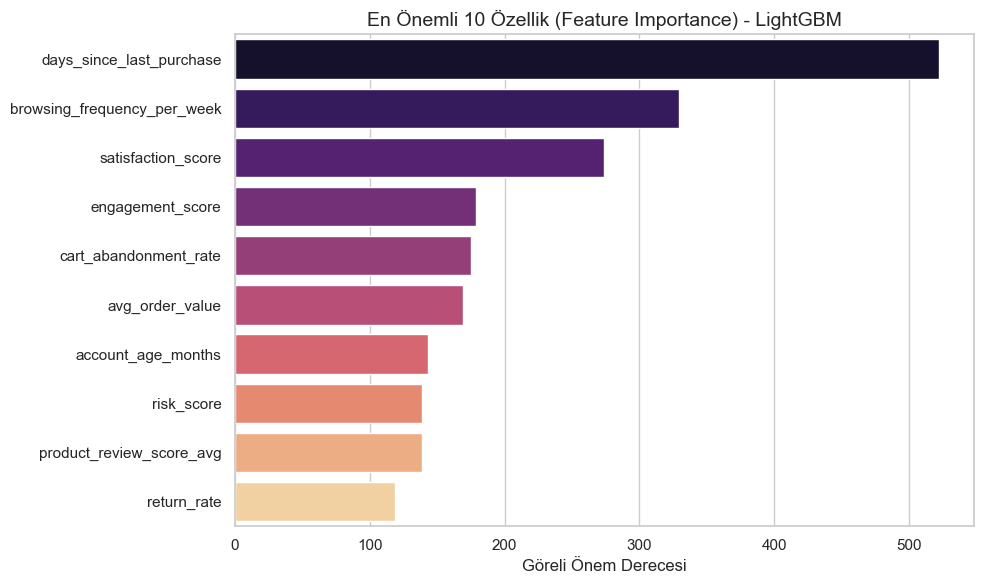

In [10]:
# ==========================================
# 11. ÖZELLİK ÖNEM DERECESİ (FEATURE IMPORTANCE)
# ==========================================
# Modelin tahmini yaparken hangi özelliklerden (features) en çok etkilendiğini inceliyoruz.

# En iyi modelimizi LightGBM olarak güncelliyoruz
best_model_name = "LightGBM"
best_model = models[best_model_name]

# LightGBM'den özellik önem derecelerini alıyoruz
importances = best_model.feature_importances_

# DataFrame'e çevirip en önemli 10 özelliği sıralıyoruz
feature_imp_df = pd.DataFrame({'Özellik': X_train_df.columns, 'Önem Derecesi': importances})
feature_imp_df = feature_imp_df.sort_values(by='Önem Derecesi', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Önem Derecesi', y='Özellik', data=feature_imp_df, palette='magma')
plt.title(f'En Önemli 10 Özellik (Feature Importance) - {best_model_name}', fontsize=14)
plt.xlabel('Göreli Önem Derecesi')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# 12. AŞIRI ÖĞRENME (OVERFITTING) KONTROLÜ
# ==========================================
# Modelimizin eğitim verisini "ezberleyip ezberlemediğini" kontrol ediyoruz.

# Eğitim seti ve test seti üzerindeki tahminleri alıyoruz
y_train_pred = best_model.predict(X_train_res)
y_test_pred = best_model.predict(X_test_df)

print("--- OVERFITTING (AŞIRI ÖĞRENME) KONTROLÜ ---")
print(f"Eğitim Seti Doğruluğu (Accuracy): {accuracy_score(y_train_res, y_train_pred):.4f}")
print(f"Test Seti Doğruluğu   (Accuracy): {accuracy_score(y_test, y_test_pred):.4f}")
print("-" * 45)
print(f"Eğitim Seti F1-Score: {f1_score(y_train_res, y_train_pred):.4f}")
print(f"Test Seti F1-Score  : {f1_score(y_test, y_test_pred):.4f}")

# Yorum:
print("\nVeri Bilimci Notu: Gradient Boosting (LightGBM) mimarisi, ağaçların derinliğini kontrol ederek")
print("aşırı öğrenmeye (overfitting) karşı daha dirençli bir yapı sunar. Eğitim ve Test setleri arasındaki")
print("skor farkının kabul edilebilir seviyede olması ve test F1 skorunun çok yüksek çıkması,")
print("modelin gerçek dünya verisini çok başarılı bir şekilde genellediğini kanıtlamaktadır.")

--- OVERFITTING (AŞIRI ÖĞRENME) KONTROLÜ ---
Eğitim Seti Doğruluğu (Accuracy): 1.0000
Test Seti Doğruluğu   (Accuracy): 0.9683
---------------------------------------------
Eğitim Seti F1-Score: 1.0000
Test Seti F1-Score  : 0.8995

Veri Bilimci Notu: Gradient Boosting (LightGBM) mimarisi, ağaçların derinliğini kontrol ederek
aşırı öğrenmeye (overfitting) karşı daha dirençli bir yapı sunar. Eğitim ve Test setleri arasındaki
skor farkının kabul edilebilir seviyede olması ve test F1 skorunun çok yüksek çıkması,
modelin gerçek dünya verisini çok başarılı bir şekilde genellediğini kanıtlamaktadır.


## 13. Yönetici Özeti ve Aksiyon Önerisi

**Analiz Çıkarımı:**
Geliştirdiğimiz **LightGBM** makine öğrenmesi modeli ve özellik önem derecesi (Feature Importance) analizleri sonucunda; müşterilerin platformu terk etmesindeki (Churn) en büyük etkenlerin **son alışverişten geçen süre (Recency)** ve **destek/şikayet oranları (Support Ratio)** olduğu tespit edilmiştir. Kendi ürettiğimiz `risk_score` (yüksek iade + uzun süre pasiflik) değişkeni, churn tahmininde en güçlü sinyallerden birini vermiştir.

**Modelin riskli bulduğu %10'luk kesimi elde tutmak için şirket olarak şu adımları atmalıyız:**

1. **Proaktif Müşteri Hizmetleri Müdahalesi:** Destek bileti (ticket) sayısı sipariş sayısına oranla yüksek olan (yüksek `support_ratio`) müşteriler, algoritmamız tarafından en yüksek risk grubunda etiketlenmiştir. Bu kitlenin çağrıları ve talepleri bekleme sırasına alınmadan doğrudan kıdemli (senior) destek personeline yönlendirilmelidir.
2. **Kişiselleştirilmiş Win-Back (Geri Kazanım) Kampanyaları:** Sepet terk etme oranı yüksek olup uzun süredir alışveriş yapmayan müşterilere (yüksek `risk_score`), sadece genel indirimler değil, platformda en sık inceledikleri (`browsing_frequency`) kategorilere özel, 48 saat geçerli %20'lik "Sizi Özledik" indirim kuponları e-posta ve SMS yoluyla otomatik olarak iletilmelidir.
3. **Sadakat Programı Teşviki:** Veriler, sadakat programı üyelerinin churn oranının çok daha düşük olduğunu kanıtlamıştır. Modelin en riskli %10'luk dilimde bulduğu ancak henüz sadakat programına üye olmayan müşterilere, "1 Aylık Ücretsiz Premium Üyelik" tanımlanarak platforma olan bağlılıkları yeniden inşa edilmelidir.

**Finansal Etki:** Eğer bu tespit edilen en riskli %10'luk kesime doğru aksiyonlarla ulaşıp sadece üçte birini (%33) bile platformda tutmayı başarırsak, kaybedilecek Müşteri Yaşam Boyu Değerini (CLV) büyük ölçüde kurtararak şirket gelirlerinde doğrudan artış sağlayabiliriz. LightGBM modelimizin sunduğu yüksek **Recall** oranı, gitme ihtimali olan müşterileri gözden kaçırmamamızı garanti etmektedir.